Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
 
plt.style.use("seaborn-v0_8")

Configuración de paths

In [ ]:
BASE       = Path(r"C:\Users\jorge gonzalez\Documents\TFG\Proyecto")
DATA_PATH  = BASE / "data" / "processed" / "livvo_day_hotel_final.parquet"
OUTPUT_DIR = BASE / "notebooks" / "00_exploracion" / "peak_analysis" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Cargar dataset del hotel 2

In [3]:
df = pd.read_parquet(DATA_PATH)
df = df[df["codigo_hotel"] == "HOTEL_2"].copy()
 
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
 
print("Rango:", df["date"].min(), "→", df["date"].max())
df.head()

Rango: 2023-01-01 00:00:00 → 2025-07-17 00:00:00


,date,codigo_hotel,roomnights,bednights,neto,stock,ocup_total,ADR
0,2023-01-01,HOTEL_2,112,227,25226.37,138,0.811594,225.235446
1,2023-01-02,HOTEL_2,114,232,25242.56,138,0.826087,221.425965
2,2023-01-03,HOTEL_2,108,220,23991.44,138,0.782609,222.142963
3,2023-01-04,HOTEL_2,110,223,20504.25,138,0.797101,186.402273
4,2023-01-05,HOTEL_2,108,215,19870.48,138,0.782609,183.985926


Serie temporal de ocupación

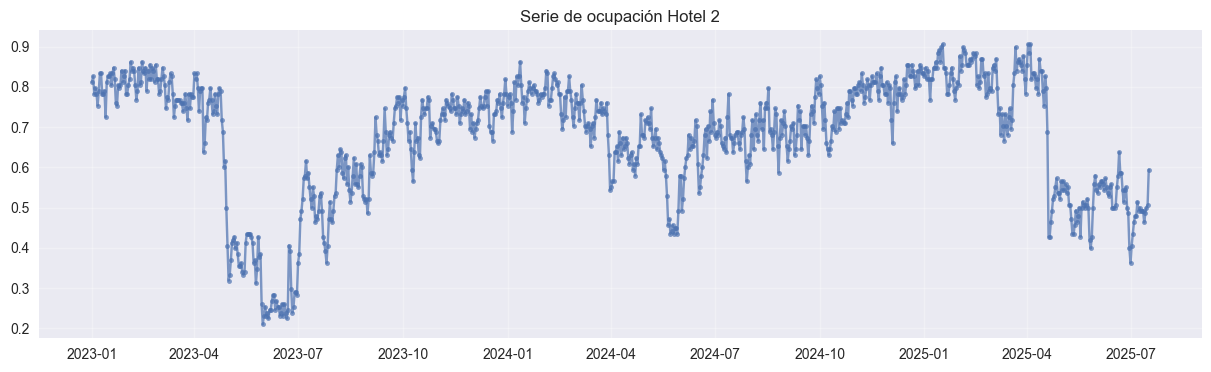

In [4]:
plt.figure(figsize=(15, 4))
plt.plot(df["date"], df["ocup_total"], marker=".", alpha=0.7)
plt.title("Serie de ocupación Hotel 2")
plt.grid(alpha=0.3)
plt.show()

Análisis estacional - Descomposición estacional

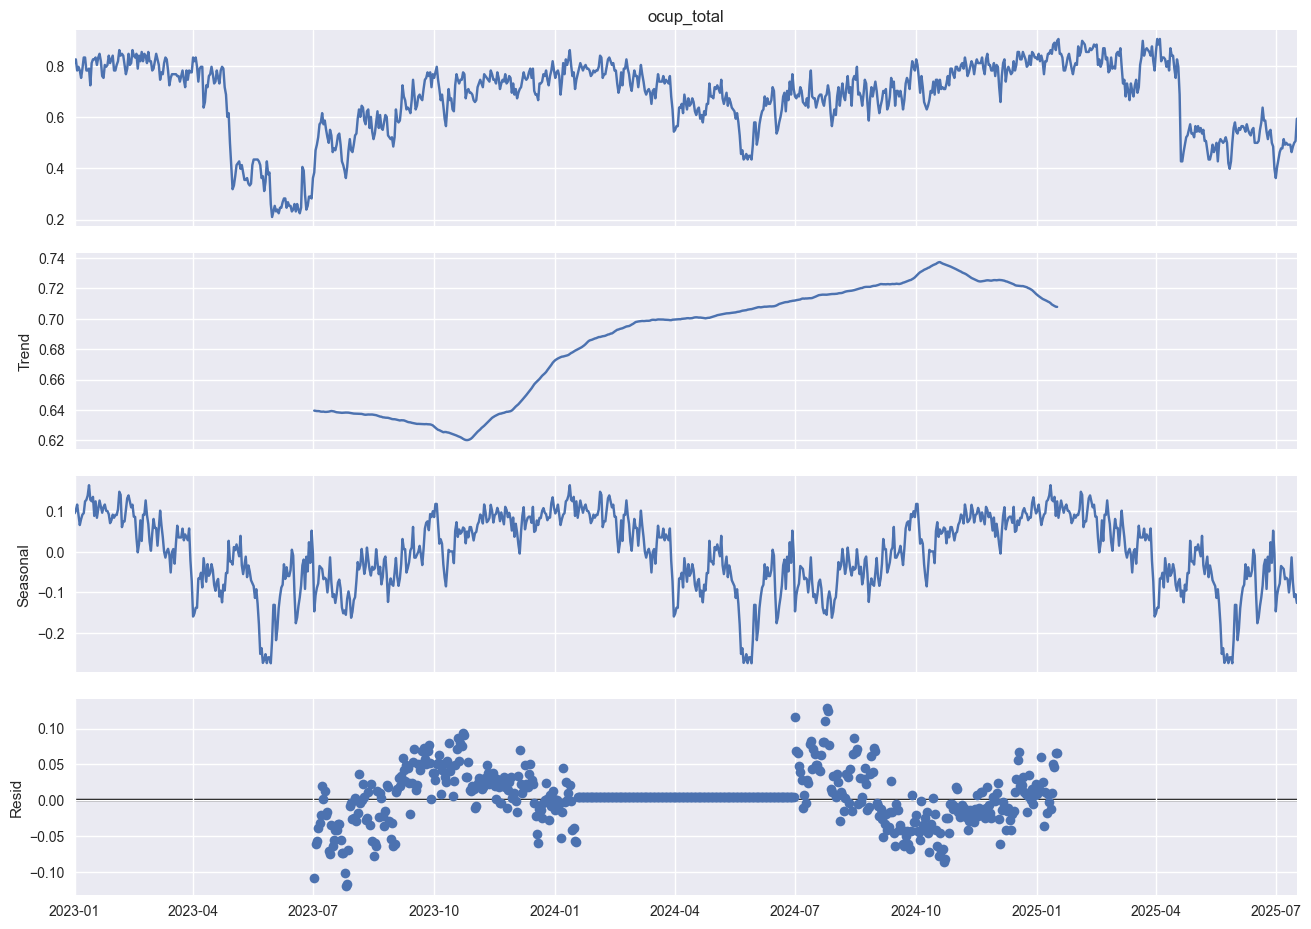

In [5]:
serie  = df.set_index("date")["ocup_total"].asfreq("D").interpolate()
decomp = seasonal_decompose(serie, model="additive", period=365)
fig    = decomp.plot()
fig.set_size_inches(14, 10)
plt.show()

Curvas Year-over-Year (YOY)

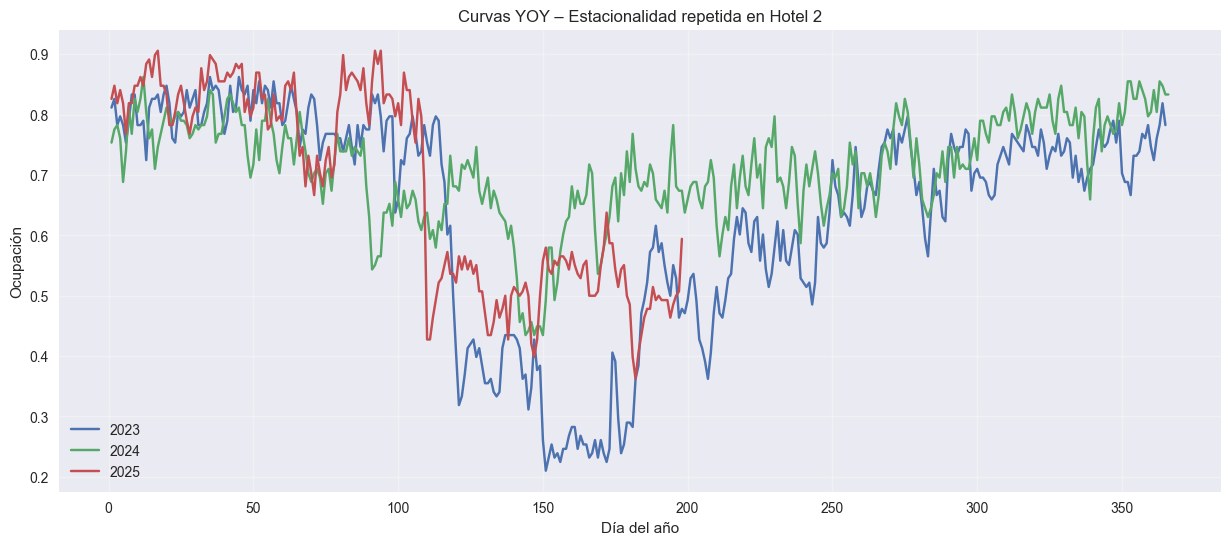

In [6]:
df["year"]      = df["date"].dt.year
df["dayofyear"] = df["date"].dt.dayofyear
 
plt.figure(figsize=(15, 6))
for y in sorted(df["year"].unique()):
    subset = df[df["year"] == y]
    plt.plot(subset["dayofyear"], subset["ocup_total"], label=str(y))
 
plt.title("Curvas YOY – Estacionalidad repetida en Hotel 2")
plt.xlabel("Día del año")
plt.ylabel("Ocupación")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Suavizado de la serie 

In [7]:
df["ocup_smooth"] = (
    df["ocup_total"]
    .rolling(30, center=True, min_periods=1)
    .mean()
)
df["year"] = df["date"].dt.year

Procesar cada año individualmente

In [8]:
all_segments  = []
annual_points = []
 
for year in sorted(df["year"].unique()):
 
    year_df = df[df["year"] == year].copy()
    year_df["trend"] = year_df["ocup_smooth"].diff(7)
 
    threshold_up   = year_df["trend"].quantile(0.75)
    threshold_down = year_df["trend"].quantile(0.25)
 
    def classify_regime(x):
        if x >= threshold_up:
            return "UP"
        elif x <= threshold_down:
            return "DOWN"
        return "FLAT"
 
    year_df["regime"]     = year_df["trend"].apply(classify_regime)
    year_df["segment_id"] = (year_df["regime"] != year_df["regime"].shift()).cumsum()
 
    segments = year_df.groupby("segment_id").agg(
        start    = ("date", "min"),
        end      = ("date", "max"),
        regime   = ("regime", "first"),
        mean_occ = ("ocup_total", "mean"),
        max_occ  = ("ocup_total", "max"),
        min_occ  = ("ocup_total", "min"),
        duration = ("date", "count")
    ).reset_index()
 
    segments = segments[
        (segments["duration"] >= 12) &
        (segments["regime"].isin(["UP", "DOWN"]))
    ]
 
    segments["year"]     = year
    segments["mid_date"] = segments["start"] + (segments["end"] - segments["start"]) / 2
 
    def classify_season_type(regime):
        if regime == "UP":
            return "PEAK_BUILDUP"
        elif regime == "DOWN":
            return "VALLEY_DROP"
        return "MID"
 
    segments["season_type"] = segments["regime"].apply(classify_season_type)
    all_segments.append(segments)
 
    max_row = year_df.loc[year_df["ocup_smooth"].idxmax()]
    annual_points.append({
        "year": year, "point_type": "MAX",
        "point_date": max_row["date"], "point_occ": max_row["ocup_smooth"]
    })
 
    min_row = year_df.loc[year_df["ocup_smooth"].idxmin()]
    annual_points.append({
        "year": year, "point_type": "MIN",
        "point_date": min_row["date"], "point_occ": min_row["ocup_smooth"]
    })

Consolidar Outputs

In [9]:
segments_final = pd.concat(all_segments, ignore_index=True)
points_final   = pd.DataFrame(annual_points)
 
segments_final["point_type"] = None
segments_final["point_date"] = pd.NaT
segments_final["point_occ"]  = np.nan
 
for i, seg in segments_final.iterrows():
    year_points = points_final[points_final["year"] == seg["year"]]
    for _, p in year_points.iterrows():
        if seg["start"] <= p["point_date"] <= seg["end"]:
            segments_final.loc[i, "point_type"] = p["point_type"]
            segments_final.loc[i, "point_date"] = p["point_date"]
            segments_final.loc[i, "point_occ"]  = p["point_occ"]

Export

In [10]:
output_path = OUTPUT_DIR / "peak_Hotel2.parquet"
segments_final.to_parquet(output_path, index=False)
print(f"✅ Guardado en: {output_path}")
print("\nPreview:")
print(segments_final.head())

✅ Guardado en: C:\Users\jorge gonzalez\Documents\TFG\Proyecto_clean\notebooks\00_exploracion\peak_analysis\outputs\peak_Hotel2.parquet

Preview:
   segment_id      start        end regime  mean_occ   max_occ   min_occ  \
0           2 2023-03-04 2023-03-17   DOWN  0.788302  0.847826  0.724638   
1           6 2023-04-14 2023-06-15   DOWN  0.433977  0.797101  0.210145   
2           8 2023-06-20 2023-07-23     UP  0.437127  0.615942  0.224638   
3          10 2023-08-01 2023-08-17     UP  0.578431  0.644928  0.492754   
4          12 2023-08-31 2023-09-24     UP  0.646377  0.746377  0.485507   

   duration  year            mid_date   season_type point_type point_date  \
0        14  2023 2023-03-10 12:00:00   VALLEY_DROP       None        NaT   
1        63  2023 2023-05-15 00:00:00   VALLEY_DROP        MIN 2023-06-14   
2        34  2023 2023-07-06 12:00:00  PEAK_BUILDUP       None        NaT   
3        17  2023 2023-08-09 00:00:00  PEAK_BUILDUP       None        NaT   
4        25  

Visualización

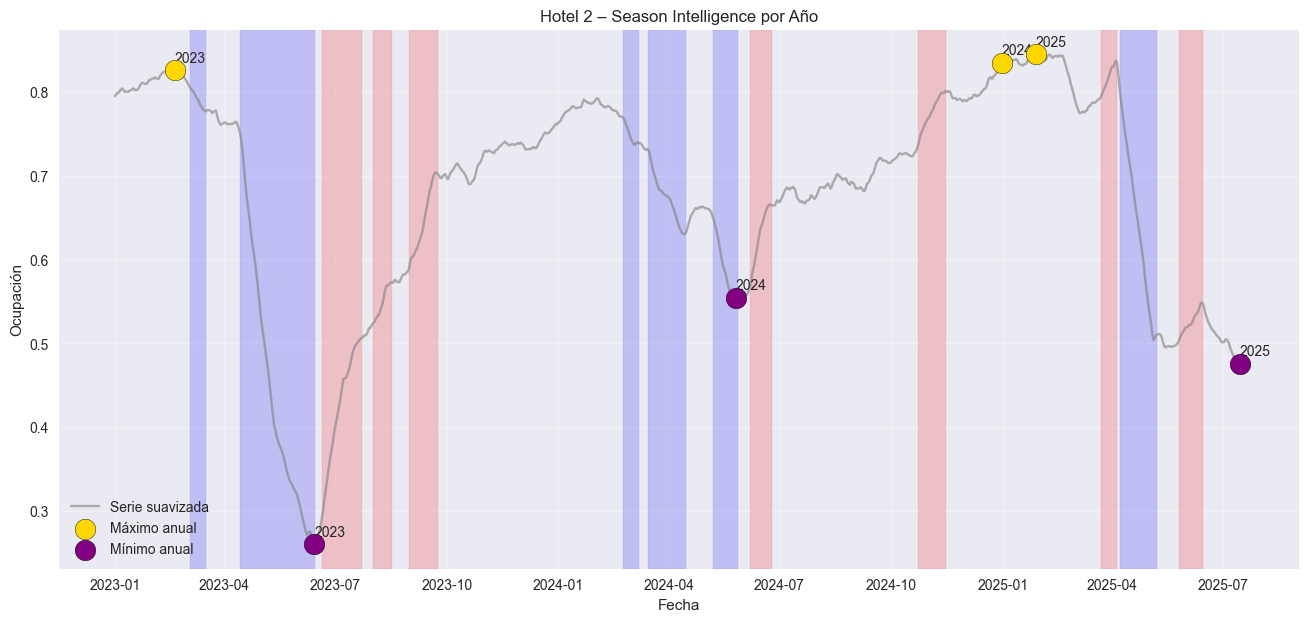

In [11]:
plt.figure(figsize=(16, 7))
 
plt.plot(df["date"], df["ocup_smooth"],
         color="gray", alpha=0.6, label="Serie suavizada")
 
for _, r in segments_final.iterrows():
    color = "red" if r["regime"] == "UP" else "blue"
    plt.axvspan(r["start"], r["end"], color=color, alpha=0.18)
 
max_points = points_final[points_final["point_type"] == "MAX"]
plt.scatter(max_points["point_date"], max_points["point_occ"],
            color="gold", s=220, edgecolor="black",
            label="Máximo anual", zorder=5)
 
min_points = points_final[points_final["point_type"] == "MIN"]
plt.scatter(min_points["point_date"], min_points["point_occ"],
            color="purple", s=220, edgecolor="black",
            label="Mínimo anual", zorder=5)
 
for _, r in points_final.iterrows():
    plt.text(r["point_date"], r["point_occ"] + 0.01, str(r["year"]), fontsize=10)
 
plt.title("Hotel 2 – Season Intelligence por Año")
plt.xlabel("Fecha")
plt.ylabel("Ocupación")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# CONCLUSIÓN FINAL – SEASON INTELLIGENCE DEL HOTEL 2 (VACACIONAL)

En este análisis se ha desarrollado un sistema de **Season Intelligence** específico para el Hotel 2, adaptado a su naturaleza claramente **vacacional**, donde la demanda no depende de eventos puntuales externos, sino de **patrones estacionales estructurales que se repiten cada año**.

A diferencia del Hotel 1 (urbano), donde los picos pueden estar asociados a eventos concretos de ciudad, en el Hotel 2 la ocupación responde principalmente a ciclos vacacionales recurrentes. Por ello, el análisis se ha rediseñado para detectar de forma más precisa:

- periodos de crecimiento acelerado de demanda (**PEAK BUILDUP**)
- periodos de caída estructural (**VALLEY DROP**)
- máximos anuales de ocupación
- mínimos anuales de ocupación

Todo ello de forma individual para cada año, permitiendo una integración mucho más coherente con el dashboard y su filtrado temporal.

---

# Enfoque metodológico aplicado

El análisis sigue una lógica adaptada al comportamiento real del hotel vacacional:

1. Análisis exploratorio de la serie temporal histórica de ocupación.
2. Identificación de patrones repetitivos mediante curvas Year-over-Year (YOY).
3. Suavizado de la serie para eliminar ruido diario.
4. Cálculo de pendientes semanales para detectar movimientos estructurales.
5. Segmentación anual en periodos de subida pronunciada (**UP**) y bajada pronunciada (**DOWN**).
6. Identificación del punto máximo anual.
7. Identificación del punto mínimo anual.
8. Exportación del resultado consolidado a parquet para visualización en dashboard.

Este enfoque permite analizar no únicamente valores extremos aislados, sino también los procesos de subida y caída que explican la dinámica estacional completa del hotel.

---

# Interpretación de resultados

## 1. El Hotel 2 presenta una estacionalidad muy marcada y altamente repetitiva

Los datos de 2023, 2024 y 2025 muestran patrones muy consistentes:

- máximos recurrentes durante periodos de alta demanda vacacional
- caídas pronunciadas posteriores
- recuperaciones graduales antes de nuevas temporadas altas

Esto confirma que el Hotel 2 opera bajo una lógica de demanda altamente predecible.

---

## 2. Los mínimos anuales muestran una clara recurrencia estacional

Los mínimos detectados fueron:

### 2023
**14 de junio de 2023**
Ocupación suavizada mínima: **26.0%**

Coincide con el periodo de mayor caída estructural del año tras la temporada alta inicial.

### 2024
**26 de mayo de 2024**
Ocupación suavizada mínima: **55.5%**

Aunque sigue existiendo valle estacional, la caída fue considerablemente menos agresiva que en 2023.

### 2025
El mínimo anual aparece en una fase reciente de ajuste tras el pico de comienzos de año, mostrando una caída menos extrema que la observada en 2023.

Esto refleja una posible estabilización progresiva del comportamiento operativo.

---

## 3. Los máximos anuales mantienen niveles muy elevados

Los máximos anuales siguen situándose en niveles muy altos de ocupación:

- **2023:** ~82%
- **2024:** ~84%
- **2025:** ~85%

Esto demuestra que el Hotel 2 mantiene una capacidad sólida de capturar demanda en temporada alta.

Además, el máximo de 2025 representa el nivel más alto de toda la serie analizada, indicando un posible fortalecimiento de la demanda vacacional.

---

## 4. La dinámica de subida y bajada aporta más valor que analizar solo picos aislados

La nueva segmentación permite identificar:

### 2023
- fuerte caída entre abril y junio
- recuperación progresiva entre junio y septiembre

### 2024
- múltiples fases de descenso entre febrero y mayo
- recuperación clara durante verano y último trimestre

### 2025
- fuerte crecimiento en Q1
- corrección importante en abril-mayo
- recuperación posterior

Esto aporta una visión mucho más rica que simplemente detectar días concretos de máxima ocupación.

---

# Conclusiones del análisis

## 1. El Hotel 2 está dominado por patrones estacionales estructurales

El comportamiento del hotel responde claramente a ciclos vacacionales recurrentes y no a shocks externos puntuales.

## 2. El análisis anual mejora significativamente la interpretabilidad

La segmentación por año evita mezclar patrones de distintos ejercicios y permite que el dashboard muestre información coherente cuando el usuario filtra temporalmente.

## 3. Los máximos y mínimos anuales facilitan la lectura ejecutiva

Permiten identificar rápidamente:

- cuándo se alcanza el mejor momento comercial
- cuándo aparece el mayor riesgo operativo

## 4. La metodología es robusta para hoteles vacacionales

El análisis de tramos de subida y bajada estructural representa mejor la realidad operativa que un enfoque basado únicamente en forecast.

---

# Conclusión global

El Hotel 2 presenta un comportamiento **altamente estacional, recurrente y relativamente predecible**, propio de un activo vacacional maduro.

La metodología de *Season Intelligence* permite capturar de forma más precisa:

- ciclos anuales de demanda
- fases de expansión y contracción
- máximos y mínimos relevantes

Generando una herramienta mucho más útil para visualización en dashboard y para la toma de decisiones comerciales basadas en comportamiento histórico real.